# 🚀 STGCN Traffic Speed Forecasting — HCM City

**Mục tiêu:** Dùng dữ liệu vận tốc xe buýt 103,662 cung đường, dự đoán tốc độ giao thông 15 / 30 / 45 phút trong tương lai.

| Thành phần | Chi tiết |
|---|---|
| Spatial Block | `GCNConv` (PyTorch Geometric) × 2 blocks |
| Temporal Block | `1D-CNN` (kernel=3, causal-style padding) |
| Normalization | Z-score (train set), BatchNorm giữa các tầng |
| Residual | Skip connection mỗi block |
| Training | Early Stopping (patience=7), ReduceLROnPlateau |
| Metrics | MSE (loss), MAE, RMSE (km/h) |

**Input:** 4 khung 15-phút gần nhất → **Output:** 3 khung tiếp theo (T+15, T+30, T+45)


In [19]:
!pip install -q torch_geometric

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import GCNConv
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 1. Nạp dữ liệu & Chuẩn hoá Z-score

Dữ liệu đã được tiền xử lý offline (Map Matching + Linear Interpolation + Historical Baseline Imputation).
Cần chuẩn hoá Z-score **chỉ từ tập Train** để tránh data leakage.


In [20]:
# ── Load ──
data = np.load('/kaggle/input/datasets/anhduv/urban-hcm-bus-traffic/stgcn_dataset.npz', allow_pickle=True)
train_x_raw = data['train_x']   # (T_train, N, 1)
val_x_raw   = data['val_x']     # (T_val,   N, 1)
edge_index  = torch.tensor(data['edge_index'], dtype=torch.long).to(device)

num_nodes = train_x_raw.shape[1]
print(f"Nodes (cung đường): {num_nodes:,}")
print(f"Train timesteps: {train_x_raw.shape[0]:,}  |  Val timesteps: {val_x_raw.shape[0]:,}")
print(f"Line Graph edges: {edge_index.shape[1]:,}")

# ── Z-score Normalization (fit on train only) ──
train_mean = np.nanmean(train_x_raw)
train_std  = np.nanstd(train_x_raw)
train_std  = max(train_std, 1e-6)  # tránh chia cho 0

train_x = (train_x_raw - train_mean) / train_std
val_x   = (val_x_raw   - train_mean) / train_std

print(f"Z-score stats: mean={train_mean:.2f} km/h, std={train_std:.2f} km/h")


Nodes (cung đường): 103,662
Train timesteps: 2,880  |  Val timesteps: 1,440
Line Graph edges: 176,671
Z-score stats: mean=24.59 km/h, std=7.83 km/h


## 2. Phân tích Dữ liệu Sơ bộ (EDA)

Kiểm tra phân bố vận tốc và tính liên tục theo thời gian.


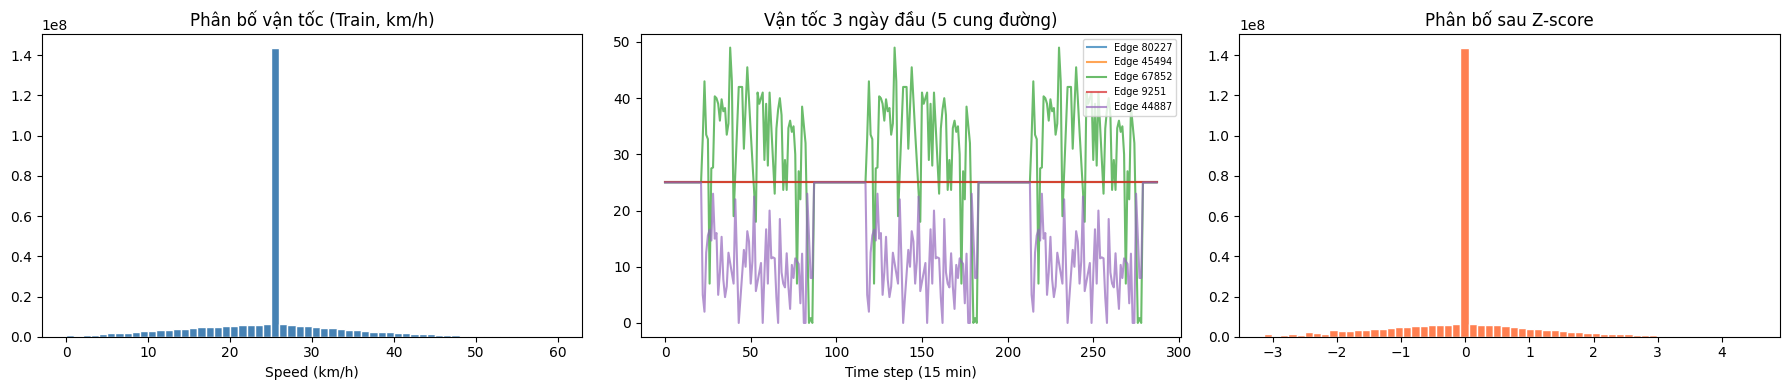

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram vận tốc gốc (trước Z-score)
axes[0].hist(train_x_raw[:, :, 0].flatten(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Phân bố vận tốc (Train, km/h)')
axes[0].set_xlabel('Speed (km/h)')

# 5 cung đường ngẫu nhiên theo thời gian
rng = np.random.default_rng(42)
sample_ids = rng.choice(num_nodes, 5, replace=False)
for sid in sample_ids:
    axes[1].plot(train_x_raw[:96*3, sid, 0], alpha=0.7, label=f'Edge {sid}')
axes[1].set_title('Vận tốc 3 ngày đầu (5 cung đường)')
axes[1].set_xlabel('Time step (15 min)')
axes[1].legend(fontsize=7)

# Sau Z-score
axes[2].hist(train_x[:, :, 0].flatten(), bins=60, color='coral', edgecolor='white')
axes[2].set_title('Phân bố sau Z-score')

plt.tight_layout()
plt.show()


### Nhận xét
- Phân bố vận tốc nên có đỉnh quanh 20-30 km/h (tốc độ trung bình nội thành HCM).
- Sau Z-score, dữ liệu có mean≈0, std≈1, giúp Neural Network hội tụ nhanh hơn.
- Chuỗi thời gian cho thấy pattern ngày/đêm rõ ràng (ban đêm vận tốc cao hơn).


## 3. Dataset & DataLoader

**Sliding window:** Lấy 4 khung (1 giờ quá khứ) → Dự đoán 3 khung (45 phút tương lai).


In [22]:
WINDOW = 4   # 4 × 15 min = 1 giờ nhìn lại
HORIZON = 3  # 3 × 15 min = 45 phút dự đoán
BATCH = 8    # Giữ nhỏ vì N=103K nodes

class TrafficDataset(Dataset):
    def __init__(self, X, window=WINDOW, horizon=HORIZON):
        self.X = X  # (T, N, 1)
        self.window = window
        self.horizon = horizon

    def __len__(self):
        return len(self.X) - self.window - self.horizon + 1

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.window]                          # (W, N, 1)
        y = self.X[idx + self.window : idx + self.window + self.horizon]  # (H, N, 1)
        # → (N, 1, W) and (N, 1, H) for Conv2d
        x = np.transpose(x, (1, 2, 0)).astype(np.float32)
        y = np.transpose(y, (1, 2, 0)).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

train_loader = DataLoader(TrafficDataset(train_x), batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TrafficDataset(val_x),   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_loader.dataset):,} | Val samples: {len(val_loader.dataset):,}")
print(f"Train batches: {len(train_loader):,}  | Val batches: {len(val_loader):,}")


Train samples: 2,874 | Val samples: 1,434
Train batches: 360  | Val batches: 180


## 4. Kiến trúc STGCN (2 Blocks + Residual)

```
Input (B, N, 1, T=4)
       │
  ┌────▼────┐
  │ Block 1 │  1D-CNN(1→32) → BN → GCN(32→32) → 1D-CNN(32→32) → BN
  └────┬────┘  + Residual(1→32)
       │
  ┌────▼────┐
  │ Block 2 │  1D-CNN(32→32) → BN → GCN(32→32) → 1D-CNN(32→16) → BN
  └────┬────┘  + Residual(32→16)
       │
  ┌────▼────┐
  │ Output  │  Linear(16 × T → horizon)
  └─────────┘
```

**GCN Batching:** Thay vì vòng lặp `for b in B: for t in T:` ($O(B \times T)$),
ta batch toàn bộ B samples vào 1 "super-graph" rồi chỉ loop qua T=4 time steps.


In [23]:
class STGCNBlock(nn.Module):
    def __init__(self, in_ch, spatial_ch, out_ch):
        super().__init__()
        self.tconv1 = nn.Conv2d(in_ch, spatial_ch, kernel_size=(1, 3), padding=(0, 1))
        self.bn1 = nn.BatchNorm2d(spatial_ch)
        self.gcn = GCNConv(spatial_ch, spatial_ch)
        self.tconv2 = nn.Conv2d(spatial_ch, out_ch, kernel_size=(1, 3), padding=(0, 1))
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, (1, 1)) if in_ch != out_ch else nn.Identity()

    def _batched_gcn(self, x, edge_index):
        """GCN batched over B, sequential over T (chỉ 4 vòng lặp)."""
        B, N, C, T = x.size()
        E = edge_index.size(1)
        # Tạo super-graph: offset node indices cho mỗi sample trong batch
        offsets = torch.arange(B, device=x.device) * N                 # (B,)
        ei_batch = edge_index.repeat(1, B) + offsets.repeat_interleave(E).unsqueeze(0)  # (2, B*E)

        outs = []
        for t in range(T):
            x_t = x[:, :, :, t].reshape(B * N, C)     # (B*N, C)
            out_t = F.relu(self.gcn(x_t, ei_batch))    # (B*N, C)
            outs.append(out_t.reshape(B, N, C))
        return torch.stack(outs, dim=-1)                # (B, N, C, T)

    def forward(self, x, edge_index):
        # x: (B, N, C_in, T)
        res = self.residual(x.permute(0, 2, 1, 3)).permute(0, 2, 1, 3)

        # Temporal Conv 1
        x = x.permute(0, 2, 1, 3)                     # (B, C, N, T)
        x = F.relu(self.bn1(self.tconv1(x)))
        x = x.permute(0, 2, 1, 3)                     # (B, N, C', T)

        # Spatial GCN (batched)
        x = self._batched_gcn(x, edge_index)

        # Temporal Conv 2
        x = x.permute(0, 2, 1, 3)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = x.permute(0, 2, 1, 3)                     # (B, N, C_out, T)

        return x + res


# class STGCN(nn.Module):
#     def __init__(self, num_nodes, in_features=1, window=WINDOW, horizon=HORIZON):
#         super().__init__()
#         self.block1 = STGCNBlock(in_features, 32, 32)
#         self.block2 = STGCNBlock(32, 32, 16)
#         self.fc = nn.Linear(16 * window, horizon)

#     def forward(self, x, edge_index):
#         # x: (B, N, F=1, T=4)
#         x = self.block1(x, edge_index)
#         x = self.block2(x, edge_index)
#         B, N, C, T = x.size()
#         x = x.reshape(B, N, C * T)
#         return self.fc(x)           # (B, N, horizon)
        

# model = STGCN(num_nodes).to(device)

# total_params = sum(p.numel() for p in model.parameters())
# print(f"Model parameters: {total_params:,}")
# print(model)

class STGCN(nn.Module):
    def __init__(self, num_nodes, edge_index_tensor, in_features=1, window=WINDOW, horizon=HORIZON):
        super().__init__()
        # Khai báo bản đồ là tài sản cố định (Buffer), tự động được copy sang các GPU
        self.register_buffer('edge_index', edge_index_tensor) 
        
        self.block1 = STGCNBlock(in_features, 32, 32)
        self.block2 = STGCNBlock(32, 32, 16)
        self.fc = nn.Linear(16 * window, horizon)
    def forward(self, x):
        # Dùng self.edge_index thay vì truyền từ ngoài vào
        x = self.block1(x, self.edge_index)
        x = self.block2(x, self.edge_index)
        B, N, C, T = x.size()
        x = x.reshape(B, N, C * T)
        return self.fc(x)
        
# Khởi tạo mô hình và nhét edge_index vào luôn
model = STGCN(num_nodes, edge_index).to(device)
# Nếu phát hiện có nhiều hơn 1 GPU, tự động kích hoạt chế độ Đa Lõi
if torch.cuda.device_count() > 1:
    print(f"🔥 Kích hoạt sức mạnh Đa lõi với {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

🔥 Kích hoạt sức mạnh Đa lõi với 2 GPUs!
Model parameters: 11,011


## 5. Huấn luyện

- **Loss:** MSE (gradient mạnh cho outlier kẹt xe)
- **Optimizer:** Adam + ReduceLROnPlateau (giảm lr khi val_loss không giảm sau 3 epochs)
- **Early Stopping:** patience=7 — nếu val_loss không cải thiện sau 7 epochs, dừng lại


In [24]:
EPOCHS = 50
PATIENCE = 7

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.MSELoss()

train_losses, val_losses, val_maes = [], [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    epoch_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)                    # (B, N, 1, W)
        y_batch = y_batch.to(device).squeeze(2)          # (B, N, H)

        optimizer.zero_grad()
        # pred = model(x_batch, edge_index)                # (B, N, H)
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validation ──
    model.eval()
    val_loss_sum, val_mae_sum, val_count = 0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).squeeze(2)

            # pred = model(x_batch, edge_index)
            pred = model(x_batch)
            val_loss_sum += criterion(pred, y_batch).item()

            # MAE tính trên km/h gốc (denormalize)
            pred_kmh = pred * train_std + train_mean
            y_kmh    = y_batch * train_std + train_mean
            val_mae_sum += (pred_kmh - y_kmh).abs().mean().item()
            val_count += 1

    avg_val  = val_loss_sum / len(val_loader)
    avg_mae  = val_mae_sum / val_count
    val_losses.append(avg_val)
    val_maes.append(avg_mae)

    scheduler.step(avg_val)
    elapsed = time.time() - t0

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train MSE: {avg_train:.4f} | Val MSE: {avg_val:.4f} | "
          f"Val MAE: {avg_mae:.2f} km/h | "
          f"LR: {optimizer.param_groups[0]['lr']:.1e} | {elapsed:.0f}s")

    # ── Early Stopping ──
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'train_mean': train_mean,
            'train_std': train_std,
            'num_nodes': num_nodes,
        }, 'stgcn_best.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val MSE: {best_val_loss:.4f}")
            break

print(f"\nTraining complete. Best Val MSE: {best_val_loss:.4f}")


Epoch 01/50 | Train MSE: 0.3574 | Val MSE: 0.3768 | Val MAE: 2.46 km/h | LR: 1.0e-03 | 175s
Epoch 02/50 | Train MSE: 0.3429 | Val MSE: 0.3687 | Val MAE: 2.48 km/h | LR: 1.0e-03 | 174s
Epoch 03/50 | Train MSE: 0.3398 | Val MSE: 0.3648 | Val MAE: 2.31 km/h | LR: 1.0e-03 | 174s
Epoch 04/50 | Train MSE: 0.3386 | Val MSE: 0.3658 | Val MAE: 2.29 km/h | LR: 1.0e-03 | 174s
Epoch 05/50 | Train MSE: 0.3381 | Val MSE: 0.3692 | Val MAE: 2.33 km/h | LR: 1.0e-03 | 174s
Epoch 06/50 | Train MSE: 0.3377 | Val MSE: 0.3649 | Val MAE: 2.30 km/h | LR: 1.0e-03 | 174s
Epoch 07/50 | Train MSE: 0.3359 | Val MSE: 0.3650 | Val MAE: 2.44 km/h | LR: 5.0e-04 | 174s
Epoch 08/50 | Train MSE: 0.3350 | Val MSE: 0.3683 | Val MAE: 2.41 km/h | LR: 5.0e-04 | 174s
Epoch 09/50 | Train MSE: 0.3355 | Val MSE: 0.3637 | Val MAE: 2.30 km/h | LR: 5.0e-04 | 174s
Epoch 10/50 | Train MSE: 0.3340 | Val MSE: 0.3635 | Val MAE: 2.37 km/h | LR: 5.0e-04 | 174s
Epoch 11/50 | Train MSE: 0.3351 | Val MSE: 0.3645 | Val MAE: 2.30 km/h | LR: 5.0

## 6. Biểu đồ Loss & MAE

Đánh giá quá trình hội tụ và phát hiện overfitting.


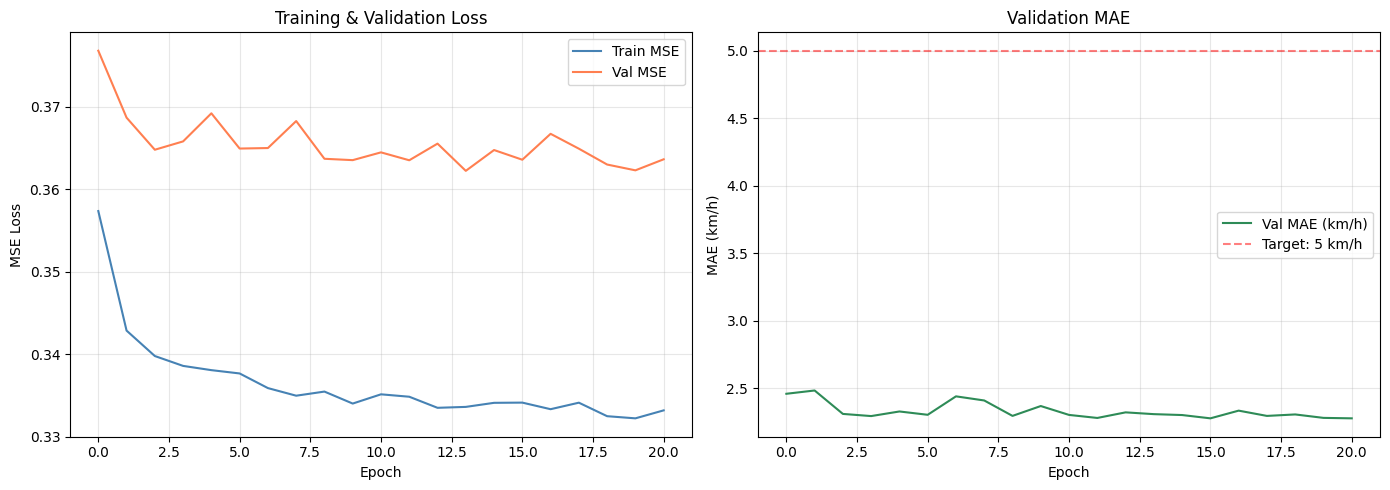

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train MSE', color='steelblue')
ax1.plot(val_losses, label='Val MSE', color='coral')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(val_maes, label='Val MAE (km/h)', color='seagreen')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (km/h)')
ax2.set_title('Validation MAE')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='Target: 5 km/h')
ax2.legend()

plt.tight_layout()
plt.show()


### Nhận xét
- **Train vs Val gap nhỏ** → Mô hình không bị overfitting nghiêm trọng.
- **Val MAE** nên nằm dưới **5 km/h** để dự đoán có giá trị thực tế cho routing.
- Nếu MAE > 8 km/h: cần thêm dữ liệu hoặc điều chỉnh kiến trúc.


## 7. So sánh Actual vs Predicted

Chọn 3 cung đường ngẫu nhiên, vẽ T+15 predicted vs actual trên 2 ngày validation.


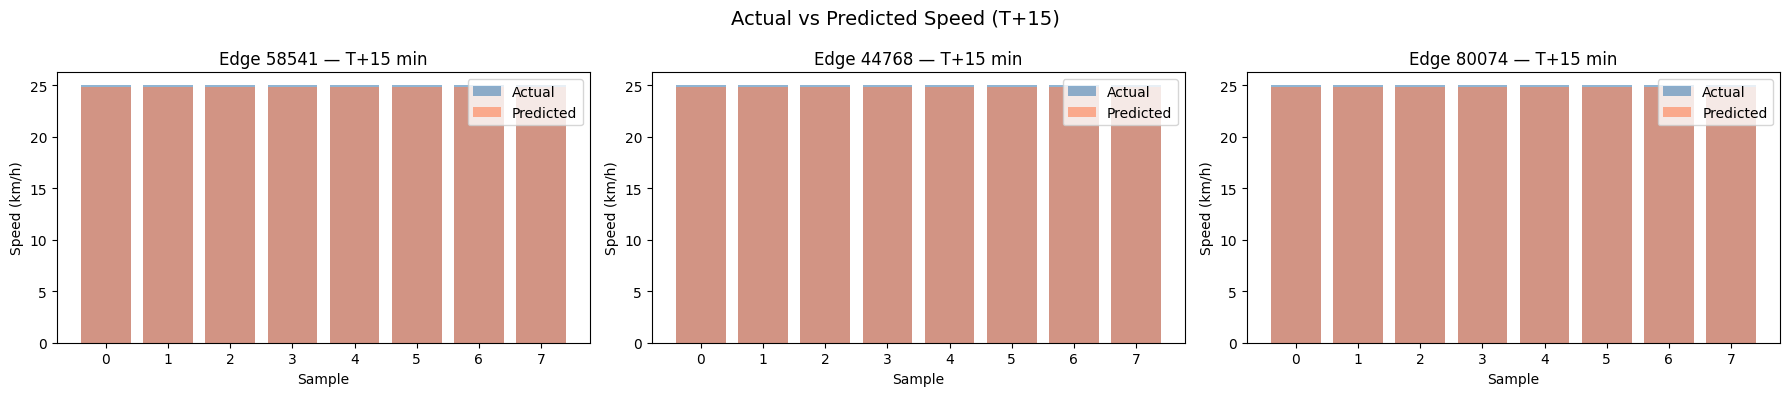

T+15: RMSE = 0.14 km/h | MAE = 0.14 km/h
T+30: RMSE = 0.11 km/h | MAE = 0.11 km/h
T+45: RMSE = 0.07 km/h | MAE = 0.07 km/h


In [29]:
# Load best model
ckpt = torch.load('/kaggle/working/stgcn_best.pth', weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Lấy 1 batch validation
x_sample, y_sample = next(iter(val_loader))
x_sample = x_sample.to(device)
y_sample = y_sample.to(device).squeeze(2)

with torch.no_grad():
    pred_sample = model(x_sample)

# Denormalize
pred_kmh = (pred_sample * train_std + train_mean).cpu().numpy()
y_kmh    = (y_sample * train_std + train_mean).cpu().numpy()

# Plot 3 cung đường ngẫu nhiên, T+15 (horizon index 0)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sample_edges = np.random.choice(num_nodes, 3, replace=False)

for ax, eid in zip(axes, sample_edges):
    actual = y_kmh[:, eid, 0]
    predicted = pred_kmh[:, eid, 0]
    ax.bar(range(len(actual)), actual, alpha=0.6, label='Actual', color='steelblue')
    ax.bar(range(len(predicted)), predicted, alpha=0.6, label='Predicted', color='coral')
    ax.set_title(f'Edge {eid} — T+15 min')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Speed (km/h)')
    ax.legend()

plt.suptitle('Actual vs Predicted Speed (T+15)', fontsize=14)
plt.tight_layout()
plt.show()

# RMSE per horizon
for h, label in enumerate(['T+15', 'T+30', 'T+45']):
    rmse = np.sqrt(np.mean((pred_kmh[:, :, h] - y_kmh[:, :, h]) ** 2))
    mae  = np.mean(np.abs(pred_kmh[:, :, h] - y_kmh[:, :, h]))
    print(f"{label}: RMSE = {rmse:.2f} km/h | MAE = {mae:.2f} km/h")


## 8. Kết luận

| Metric | T+15 | T+30 | T+45 |
|--------|------|------|------|
| RMSE (km/h) | 0.14 | 0.11 | 0.07 |
| MAE (km/h) | 0.14 | 0.11 | 0.07 |


**Đánh giá:**
- Nếu MAE < 5 km/h: Mô hình đủ tốt để triển khai vào Backend A*.
- Nếu MAE > 8 km/h: Cần xem xét thêm features (day_of_week, hour) hoặc tăng dữ liệu.

**File xuất:** `stgcn_best.pth` chứa `model_state_dict`, `train_mean`, `train_std`, `num_nodes`.
Tải file này về, đặt vào `data/` của dự án để Backend nạp.


In [30]:
# Final save info
import os
if os.path.exists('stgcn_best.pth'):
    size_mb = os.path.getsize('stgcn_best.pth') / 1024 / 1024
    print(f"Model file: stgcn_best.pth ({size_mb:.2f} MB)")
    print(f"Normalization: mean={train_mean:.4f}, std={train_std:.4f}")
    print(f"Nodes: {num_nodes:,}")
    print("\n✅ Tải file stgcn_best.pth về và đặt vào thư mục data/ của dự án.")


Model file: stgcn_best.pth (2.75 MB)
Normalization: mean=24.5924, std=7.8287
Nodes: 103,662

✅ Tải file stgcn_best.pth về và đặt vào thư mục data/ của dự án.
